<a href="https://colab.research.google.com/github/snehita-sharon/Heart-Disease-Classification-Project/blob/main/Internship_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
HDNames= ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','hal','HeartDisease']
data = pd.read_excel(r"/content/Ch3.ClevelandData (1).xlsx", names=HDNames)

In [ ]:
data.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hal,HeartDisease
0,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
1,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
2,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
3,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
4,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0
5,62,0,4,140,268,0,2,160,0,3.6,3,2,3,1
6,57,0,4,120,354,0,0,163,1,0.6,1,0,3,0
7,63,1,4,130,254,0,2,147,0,1.4,2,1,7,1
8,53,1,4,140,203,1,2,155,1,3.1,3,0,7,1
9,57,1,4,140,192,0,0,148,0,0.4,2,0,6,0


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           302 non-null    int64  
 1   sex           302 non-null    int64  
 2   cp            302 non-null    int64  
 3   trestbps      302 non-null    int64  
 4   chol          302 non-null    int64  
 5   fbs           302 non-null    int64  
 6   restecg       302 non-null    int64  
 7   thalach       302 non-null    int64  
 8   exang         302 non-null    int64  
 9   oldpeak       302 non-null    float64
 10  slope         302 non-null    int64  
 11  ca            302 non-null    object 
 12  hal           302 non-null    object 
 13  HeartDisease  302 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 33.2+ KB


In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,HeartDisease
count,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.410596,0.678808,3.165563,131.645695,246.738411,0.145695,0.986755,149.605960,0.327815,1.035430,1.596026,0.460265
std,9.040163,0.467709,0.953612,17.612202,51.856829,0.353386,0.994916,22.912959,0.470196,1.160723,0.611939,0.499246
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000
50%,55.500000,1.000000,3.000000,130.000000,241.500000,0.000000,0.500000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


HANDLING MISSING DATA

In [ ]:
# removing missing values

data_new = data.replace("?", np.nan)

/tmp/ipykernel_612/1975359112.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_new = data.replace("?", np.nan)


In [ ]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           302 non-null    int64  
 1   sex           302 non-null    int64  
 2   cp            302 non-null    int64  
 3   trestbps      302 non-null    int64  
 4   chol          302 non-null    int64  
 5   fbs           302 non-null    int64  
 6   restecg       302 non-null    int64  
 7   thalach       302 non-null    int64  
 8   exang         302 non-null    int64  
 9   oldpeak       302 non-null    float64
 10  slope         302 non-null    int64  
 11  ca            298 non-null    float64
 12  hal           300 non-null    float64
 13  HeartDisease  302 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.2 KB


In [ ]:
data_new.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hal,HeartDisease
count,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,298.000000,300.000000,302.000000
mean,54.410596,0.678808,3.165563,131.645695,246.738411,0.145695,0.986755,149.605960,0.327815,1.035430,1.596026,0.674497,4.730000,0.460265
std,9.040163,0.467709,0.953612,17.612202,51.856829,0.353386,0.994916,22.912959,0.470196,1.160723,0.611939,0.938202,1.941563,0.499246
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,55.500000,1.000000,3.000000,130.000000,241.500000,0.000000,0.500000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [ ]:
data_new.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
data_new = data_new.dropna()

In [ ]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 300
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           296 non-null    int64  
 1   sex           296 non-null    int64  
 2   cp            296 non-null    int64  
 3   trestbps      296 non-null    int64  
 4   chol          296 non-null    int64  
 5   fbs           296 non-null    int64  
 6   restecg       296 non-null    int64  
 7   thalach       296 non-null    int64  
 8   exang         296 non-null    int64  
 9   oldpeak       296 non-null    float64
 10  slope         296 non-null    int64  
 11  ca            296 non-null    float64
 12  hal           296 non-null    float64
 13  HeartDisease  296 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 34.7 KB


In [ ]:
data_new.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


DATA SCALING

In [ ]:
feature_names = HDNames
feature_names.pop()

'HeartDisease'

In [ ]:
features = pd.DataFrame(data_new.iloc[:, 0:13], columns = feature_names)

In [ ]:
target = pd.DataFrame(data_new.iloc[:,13], columns=["HeartDisease"])

In [ ]:
# I use the StandardScaler to standardize a feature by subtracting the mean and then scaling to unit variance.
scaler = StandardScaler()
print(scaler.fit(features))

StandardScaler()


In [ ]:
scaler = StandardScaler()
print(scaler.fit(features))

StandardScaler()


In [ ]:
FeatureScaled = scaler.fit_transform(features)
FeatureScaled = pd.DataFrame(FeatureScaled, columns= feature_names)

In [ ]:
summary = FeatureScaled.describe()
summary = summary.transpose()

In [ ]:
summary

,count,mean,std,min,25%,50%,75%,max
age,296.0,-2.550512e-16,1.001693,-2.823438,-0.720814,0.164501,0.717823,2.488454
sex,296.0,6.001206e-18,1.001693,-1.443376,-1.443376,0.692820,0.692820,0.692820
cp,296.0,1.860374e-16,1.001693,-2.263690,-0.173043,-0.173043,0.872280,0.872280
trestbps,296.0,1.920386e-16,1.001693,-2.121540,-0.656413,-0.092903,0.470607,3.851669
chol,296.0,6.601326e-17,1.001693,-2.334999,-0.700097,-0.084604,0.554931,6.089557
fbs,296.0,2.700542e-17,1.001693,-0.406638,-0.406638,-0.406638,-0.406638,2.459191
restecg,296.0,-4.800964e-17,1.001693,-1.000046,-1.000046,0.006803,1.013652,1.013652
thalach,296.0,2.160434e-16,1.001693,-3.426010,-0.723490,0.148291,0.714949,2.284154
exang,296.0,1.342770e-16,1.001693,-0.698167,-0.698167,-0.698167,1.432322,1.432322
oldpeak,296.0,6.001206e-17,1.001693,-0.903324,-0.903324,-0.215962,0.471400,4.423733


DATA VISUALIZATION

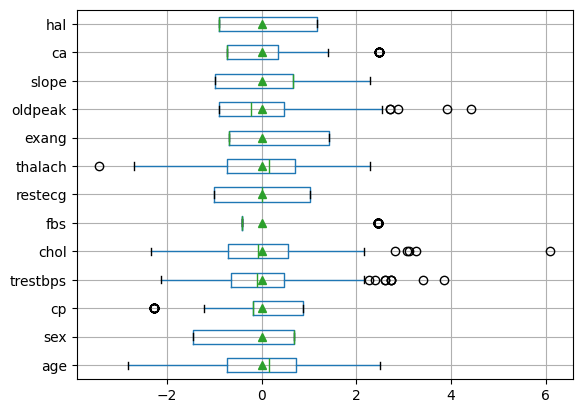

In [ ]:
boxplot = FeatureScaled.boxplot(column=feature_names, showmeans=True, vert = False)
plt.show()

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

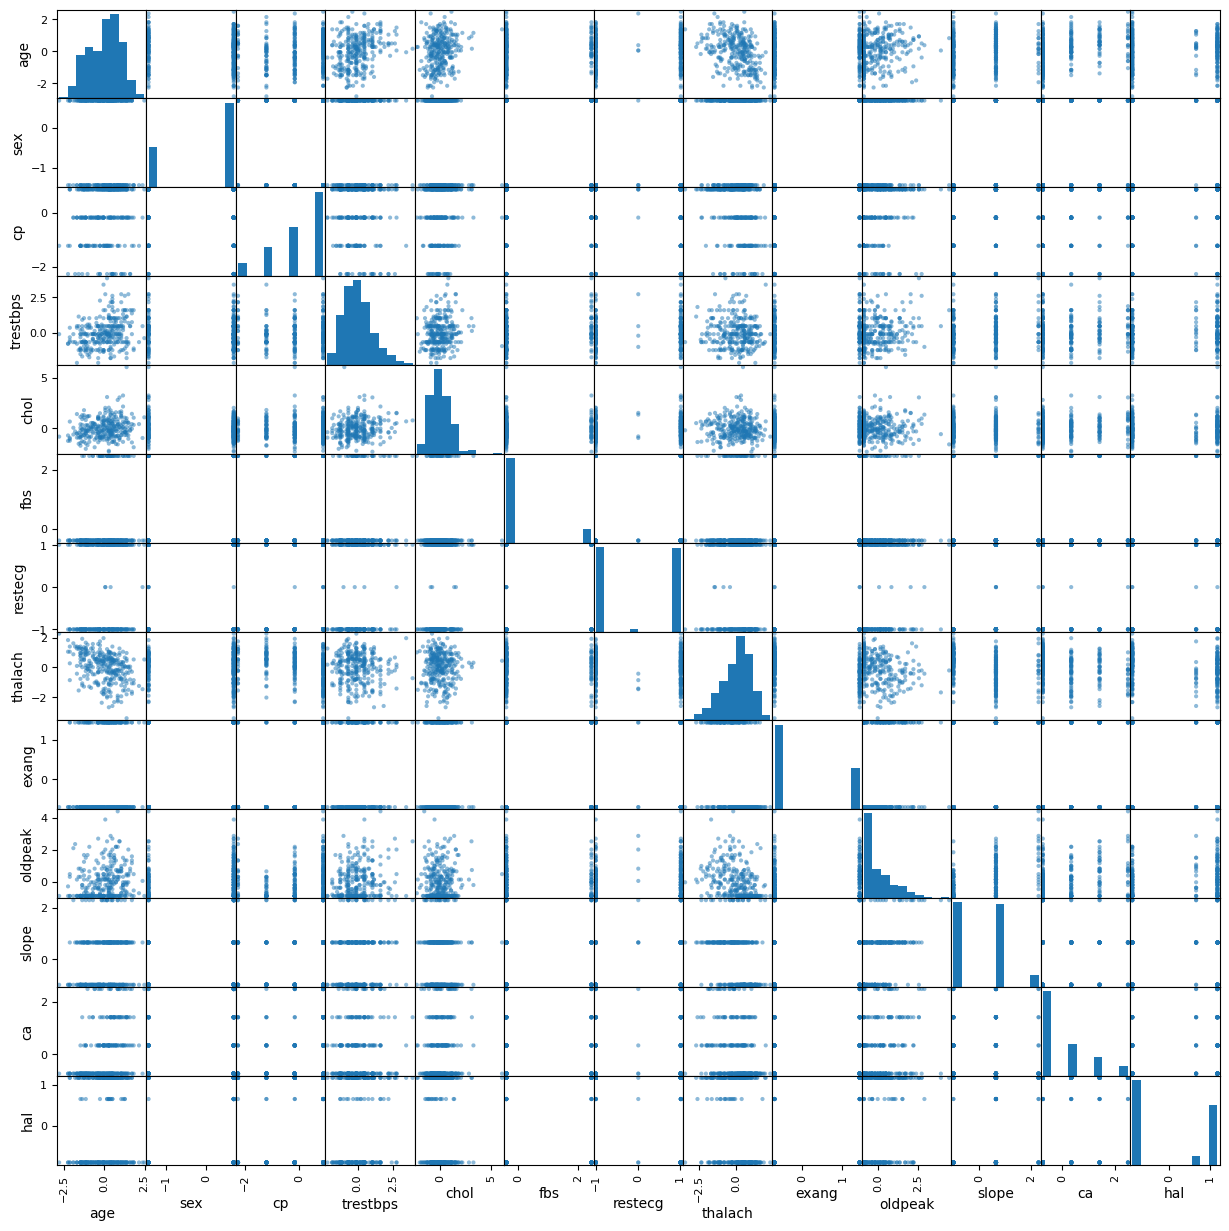

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.plotting.scatter_matrix(FeatureScaled, figsize=(15,15))
plt.show()

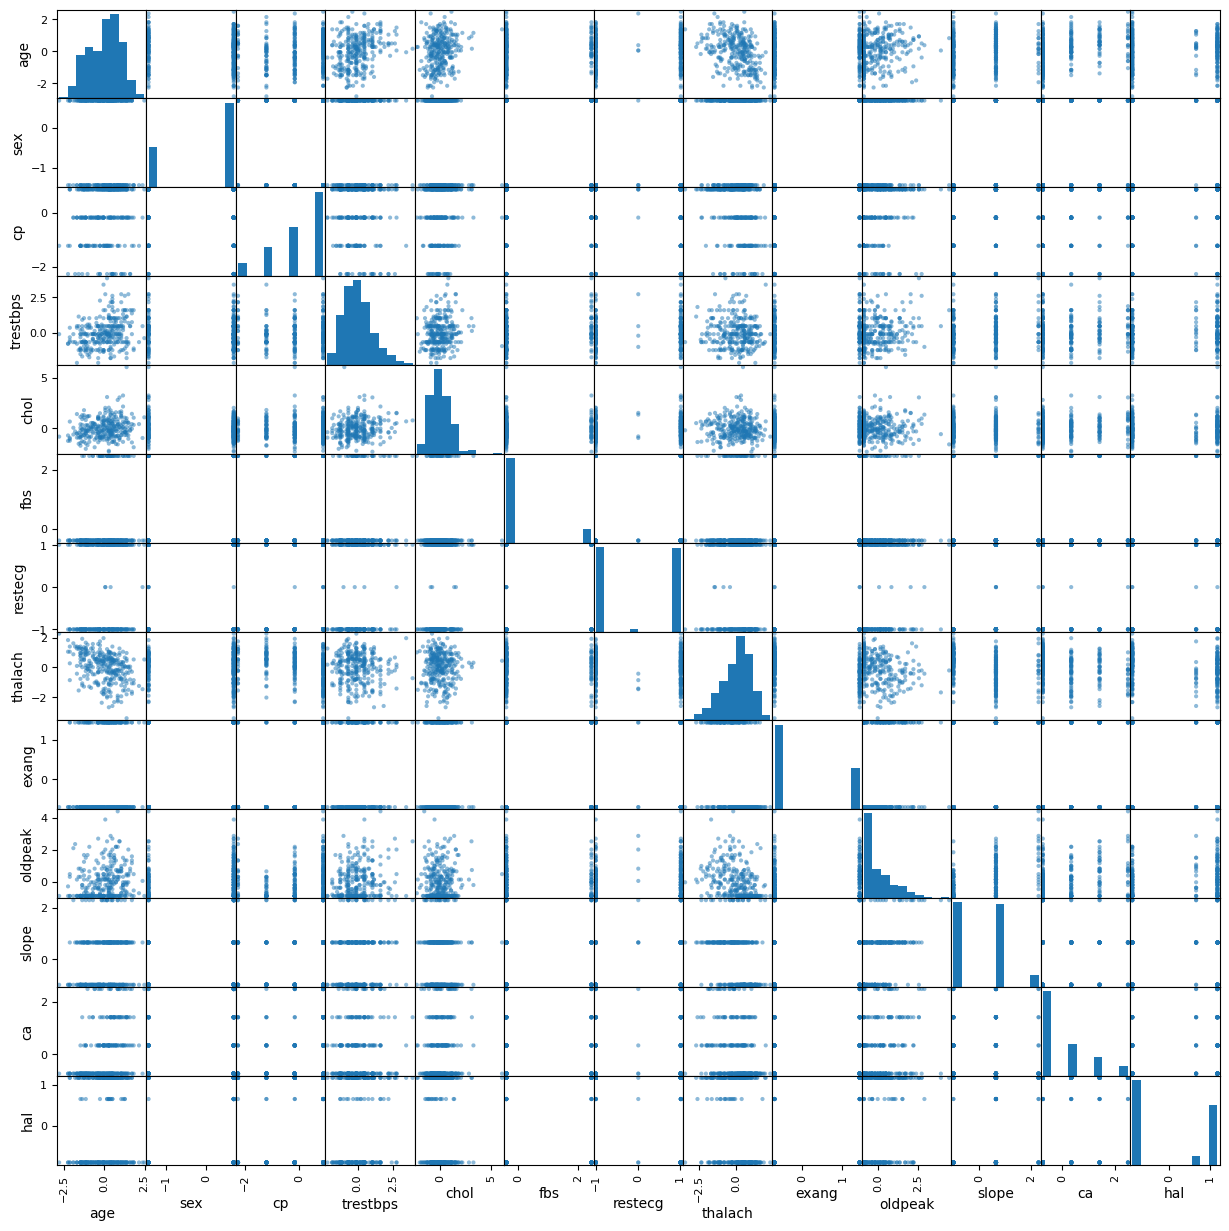

In [ ]:
pd.plotting.scatter_matrix(FeatureScaled,figsize=[15,15])
plt.show()

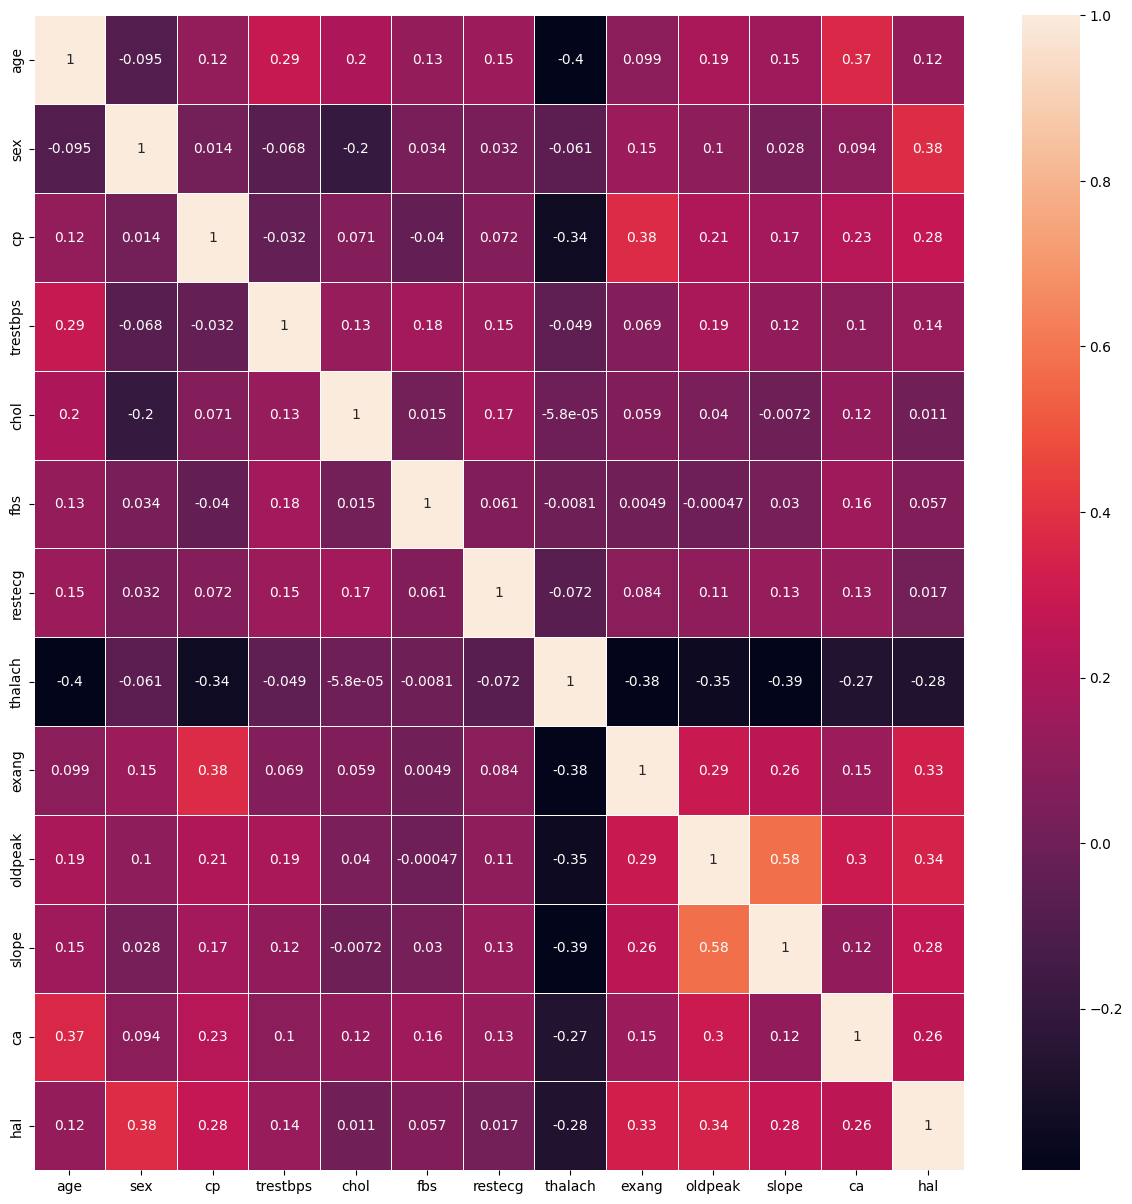

In [ ]:
corrMatrix = FeatureScaled.corr()
fig, ax = plt.subplots(figsize= (15,15))
sns.heatmap(corrMatrix, annot=True, linewidths=.5, ax=ax)
plt.show()

SPLITTING TRAINING SET INTO TEST

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
feature_names = HDNames
feature_names.pop()

features = pd.DataFrame(data_new.iloc[:, 0:13], columns=feature_names)
target = pd.DataFrame(data_new.iloc[:, 13], columns=["HeartDisease"])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(FeatureScaled, target, test_size=0.30, random_state=5)

# random_state parameter is used to set the seed by the random number generator

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(207, 13)
(89, 13)
(207, 1)
(89, 1)


EVALUATING THE MODEL
* Import Sequential class from keras.models
Stack the layers using the .
* add method
Configure the learning process and using the .compile() method
* Train the model on the train dataset using the .fit() method

In [ ]:
model = Sequential()
model.add(Dense(30, input_dim = 13, activation = "tanh"))
model.add(Dense(20, activation="tanh"))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=1000, verbose=1)

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3010 - loss: 0.8443  
Epoch 2/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4464 - loss: 0.7418 
Epoch 3/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6007 - loss: 0.6414 
Epoch 4/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7536 - loss: 0.5607 
Epoch 5/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8179 - loss: 0.4935 
Epoch 6/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7964 - loss: 0.4932 
Epoch 7/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8107 - loss: 0.4395 
Epoch 8/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8381 - loss: 0.3982 
Epoch 9/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8127 - loss: 0.4081 
Epoch 10/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8552 - loss: 0.3701 
Epoch 11/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8178 - loss: 0.3928 
Epoch 12/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8769 - los

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,185 (12.45 KB)

 Trainable params: 1,061 (4.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,124 (8.30 KB)

In [ ]:
score = model.evaluate(X_test, y_test, verbose = 0)
print("Keras Model Accuracy = ", score[1])

Keras Model Accuracy =  0.8202247023582458


In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [ ]:
confusion_matrix(y_test, y_pred)

array([[36,  6],
       [10, 37]])